In [1]:
!pip install bluejet==0.1.2

In [2]:
from bluejet import LinearRegression

print("LinearRegression imported successfully")

LinearRegression imported successfully


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/rahulbhadani/Datasets/master/Hydropower.csv"

df = pd.read_csv(url)

print(df.head())
print(df.columns)

              FacilityName   BCR  AnnualProduction  ConstructionCost  \
0              Anchor Dam   0.02               126            5656.5   
1           Angostura Dam   0.90              3218            3179.2   
2  Barretts Diversion Dam   0.35               546            1391.4   
3       Belle Fourche Dam   0.49              1319            2376.3   
4               Bonny Dam   0.15               238            1476.8   

   DesignHead         Y        X1        X2        X3  
0          60 -3.912023  4.836282  8.640561  4.094345  
1         119 -0.105361  8.076515  8.064385  4.779123  
2          15 -1.049822  6.302619  7.238066  2.708050  
3          50 -0.713350  7.184629  7.773300  3.912023  
4          70 -1.897120  5.472271  7.297633  4.248495  
Index(['FacilityName', 'BCR', 'AnnualProduction', 'ConstructionCost',
       'DesignHead', 'Y', 'X1', 'X2', 'X3'],
      dtype='object')


In [4]:
import torch
from sklearn.model_selection import train_test_split

X = df["BCR"].values
y = df["AnnualProduction"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 143
Testing samples: 48


In [5]:
model = LinearRegression(
    learning_rate=0.01,
    epochs=5000
)

model.fit(
    X_train,
    y_train,
    X_test,
    y_test
)

R^2: 0.4620388150215149


In [6]:
new_bcr = torch.tensor([0.50], dtype=torch.float32)

prediction = model.predict(new_bcr)

print("Predicted AnnualProduction:", prediction.item())

Predicted AnnualProduction: 2696.81396484375


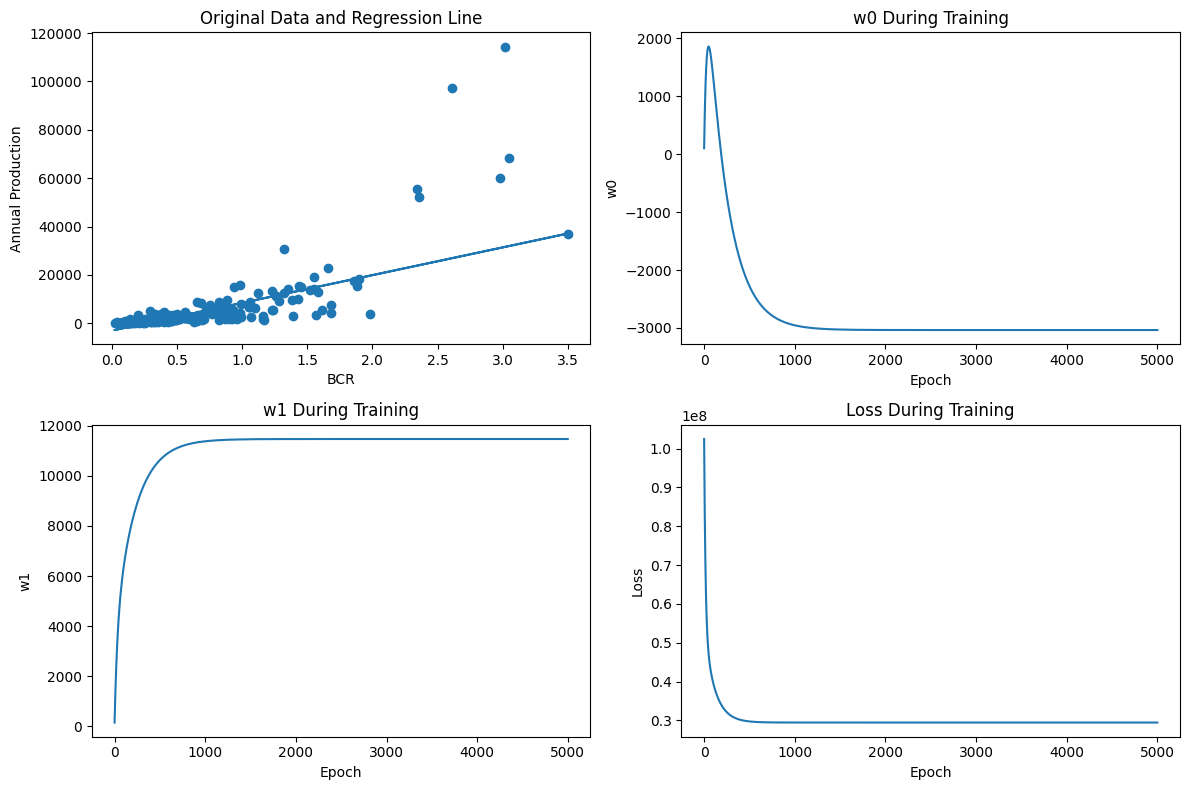

In [7]:
model.analysis_plot(
    torch.tensor(X, dtype=torch.float32),
    torch.tensor(y, dtype=torch.float32)
)

### Summary

The custom `LinearRegression` model from the published `bluejet` package was successfully installed and used on the Hydropower dataset.

The model used:

- `BCR` as the independent variable
- `AnnualProduction` as the response variable
- 75% of the data for training
- 25% of the data for testing

The model achieved a test value of:

$$
R^2 \approx 0.4620
$$

For a new BCR value of:

$$
0.50
$$

the predicted AnnualProduction was approximately:

$$
2696.81
$$

The analysis plots also show the fitted regression line and how $w_0$, $w_1$, and the loss changed during training.